In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt

deg = {'SOFT':   {'base': 90.0, 'd': 0.0844},
       'MEDIUM': {'base': 90.6, 'd': 0.0369},
       'HARD':   {'base': 91.2, 'd': 0.0521}}
FUEL        = -0.10
PIT_LOSS    = 26.4      # measured green pit cost
PIT_SC      = 12.0      # cited SC pit cost
COMPOUNDS   = ['SOFT', 'MEDIUM', 'HARD']
P_SC        = 0.0135    # your 2025 measurement
SC_DUR      = 4
Q_END       = 0.25     # SC ends per lap (memoryless); E[dur]=1/q=4
SC_LAP_TIME = 140.0
B_MAX       = 4
DELTA       = 0.4
SC_RECHARGE = 1
N_LAPS      = 57        # overwritten per circuit

def lap_time(compound, tyre_age, lap_number):
    p = deg[compound]
    return p['base'] + p['d'] * tyre_age + FUEL * lap_number

def flag_transition(f):
    if f == 0:
        return [(0, 1 - P_SC), (1, P_SC)]
    return [(1, 1 - Q_END), (0, Q_END)]

In [2]:
def solve_sdp(battery=True):
    NC, NA, NM, NF, NB = 3, N_LAPS + 1, 2, 2, B_MAX + 1
    INF = float('inf')
    V    = np.full((N_LAPS + 2, NC, NA, NM, NF, NB), INF)
    PPOL = np.full((N_LAPS + 1, NC, NA, NM, NF, NB), -1, dtype=int)
    EPOL = np.full((N_LAPS + 1, NC, NA, NM, NF, NB), 1,  dtype=int)
    V[N_LAPS + 1, :, :, 1, :, :] = 0.0
    energy_opts = [0, 1, 2] if battery else [1]
    for n in range(N_LAPS, 0, -1):
        for ci in range(NC):
            c = COMPOUNDS[ci]
            for a in range(NA):
                for m in range(NM):
                    for f in range(NF):
                        for b in range(NB):
                            best, bp, be = INF, -1, 1
                            if f == 0:
                                for e in energy_opts:
                                    if e == 0 and b == 0: continue
                                    if e == 2 and b == B_MAX: continue
                                    dt = (-DELTA if e == 0 else DELTA if e == 2 else 0.0)
                                    b2 = b - 1 if e == 0 else b + 1 if e == 2 else b
                                    if a + 1 < NA:
                                        cost = lap_time(c, a + 1, n) + dt
                                        ev = sum(p * V[n+1, ci, a+1, m, nf, b2]
                                                 for nf, p in flag_transition(f))
                                        if cost + ev < best: best, bp, be = cost + ev, -1, e
                                    for xi in range(NC):
                                        m2 = 1 if (xi != ci or m == 1) else 0
                                        cost = lap_time(COMPOUNDS[xi], 1, n) + PIT_LOSS + dt
                                        ev = sum(p * V[n+1, xi, 1, m2, nf, b2]
                                                 for nf, p in flag_transition(f))
                                        if cost + ev < best: best, bp, be = cost + ev, xi, e
                            else:
                                b2 = min(B_MAX, b + SC_RECHARGE) if battery else b
                                cost = SC_LAP_TIME
                                ev = sum(p * V[n+1, ci, a, m, nf, b2]
                                         for nf, p in flag_transition(f))
                                if cost + ev < best: best, bp, be = cost + ev, -1, 1
                                for xi in range(NC):
                                    m2 = 1 if (xi != ci or m == 1) else 0
                                    cost = SC_LAP_TIME + PIT_SC
                                    ev = sum(p * V[n+1, xi, 0, m2, nf, b2]
                                             for nf, p in flag_transition(f))
                                    if cost + ev < best: best, bp, be = cost + ev, xi, 1
                            V[n, ci, a, m, f, b] = best
                            PPOL[n, ci, a, m, f, b] = bp
                            EPOL[n, ci, a, m, f, b] = be
        if n % 10 == 0: print(f"    [battery={'ON' if battery else 'OFF'}] lap {n}")
    return V, PPOL, EPOL

In [3]:
def simulate_b(PPOL, EPOL, flags, start_comp='SOFT', b0=2, battery=True):
    ci, a, m, b, total = COMPOUNDS.index(start_comp), 0, 0, b0, 0.0
    pits, deploys = [], []
    for n in range(1, N_LAPS + 1):
        f = flags[n - 1]
        pa, ea = PPOL[n, ci, a, m, f, b], EPOL[n, ci, a, m, f, b]
        if f == 0:
            dt = (-DELTA if ea == 0 else DELTA if ea == 2 else 0.0)
            if ea == 0: deploys.append(n)
            b = b - 1 if ea == 0 else min(B_MAX, b + 1) if ea == 2 else b
            if pa == -1:
                a += 1; total += lap_time(COMPOUNDS[ci], a, n) + dt
            else:
                pits.append((n, COMPOUNDS[pa], 'green'))
                if pa != ci or m == 1: m = 1
                ci, a = pa, 1
                total += lap_time(COMPOUNDS[ci], a, n) + PIT_LOSS + dt
        else:
            if battery: b = min(B_MAX, b + SC_RECHARGE)
            if pa == -1: total += SC_LAP_TIME
            else:
                pits.append((n, COMPOUNDS[pa], 'SC'))
                if pa != ci or m == 1: m = 1
                ci, a = pa, 0
                total += SC_LAP_TIME + PIT_SC
    return total, pits, deploys

rng = np.random.default_rng(42)
def random_flags():
    seq, f = [], 0
    for _ in range(N_LAPS):
        seq.append(f)
        if f == 0:
            f = 1 if rng.random() < P_SC else 0
        else:
            f = 0 if rng.random() < Q_END else 1
    return seq

In [4]:
CIRCUITS = {
    'Monza':       {'n_laps': 53, 'base_medium': 85.0},
    'Spa':         {'n_laps': 44, 'base_medium': 107.0},
    'Silverstone': {'n_laps': 52, 'base_medium': 90.6},
    'Suzuka':      {'n_laps': 53, 'base_medium': 93.0},
}

results = {}
_deg0, _nlaps0 = copy.deepcopy(deg), N_LAPS

for name, cfg in CIRCUITS.items():
    print(f"\n=== {name} ({cfg['n_laps']} laps, medium base {cfg['base_medium']}s) ===")
    N_LAPS = cfg['n_laps']
    bmid = cfg['base_medium']
    deg['SOFT']['base'], deg['MEDIUM']['base'], deg['HARD']['base'] = bmid-0.6, bmid, bmid+0.6

    _, P_o, E_o = solve_sdp(battery=False)
    _, P_n, E_n = solve_sdp(battery=True)

    green = [0] * N_LAPS
    _, pits_off, _ = simulate_b(P_o, E_o, green, battery=False)
    _, pits_on,  _ = simulate_b(P_n, E_n, green, battery=True)

    diffs, had_sc = [], []
    for _ in range(300):
        fl = random_flags()
        t_o, _, _ = simulate_b(P_o, E_o, fl, battery=False)
        t_n, _, _ = simulate_b(P_n, E_n, fl, battery=True)
        diffs.append(t_o - t_n); had_sc.append(any(x > 0 for x in fl))
    diffs, had_sc = np.array(diffs), np.array(had_sc)

    results[name] = {
        'pit_off': pits_off[0][0] if pits_off else None,
        'pit_on':  pits_on[0][0]  if pits_on  else None,
        'val_sc':    diffs[had_sc].mean()  if had_sc.any()    else 0.0,
        'val_green': diffs[~had_sc].mean() if (~had_sc).any() else 0.0,
    }
    r = results[name]
    print(f"  pit OFF={r['pit_off']}, ON={r['pit_on']} | battery value: "
          f"SC {r['val_sc']:+.2f}s, green {r['val_green']:+.2f}s")

deg, N_LAPS = _deg0, _nlaps0


=== Monza (53 laps, medium base 85.0s) ===
    [battery=OFF] lap 50
    [battery=OFF] lap 40
    [battery=OFF] lap 30


    [battery=OFF] lap 20
    [battery=OFF] lap 10
    [battery=ON] lap 50


    [battery=ON] lap 40
    [battery=ON] lap 30


    [battery=ON] lap 20


    [battery=ON] lap 10


...

  pit OFF=23, ON=23 | battery value: SC +1.90s, green +0.80s

=== Suzuka (53 laps, medium base 93.0s) ===
    [battery=OFF] lap 50
    [battery=OFF] lap 40
    [battery=OFF] lap 30


    [battery=OFF] lap 20
    [battery=OFF] lap 10
    [battery=ON] lap 50


    [battery=ON] lap 40
    [battery=ON] lap 30


    [battery=ON] lap 20
    [battery=ON] lap 10


  pit OFF=23, ON=23 | battery value: SC +1.96s, green +0.80s


Circuit       laps  pit OFF  pit ON  Δpit   val SC  val grn
------------------------------------------------------------
Monza           53       23      23    +0   +2.09s   +0.80s
Spa             44       20      20    +0   +1.98s   +0.80s
Silverstone     52       23      23    +0   +1.90s   +0.80s
Suzuka          53       23      23    +0   +1.96s   +0.80s


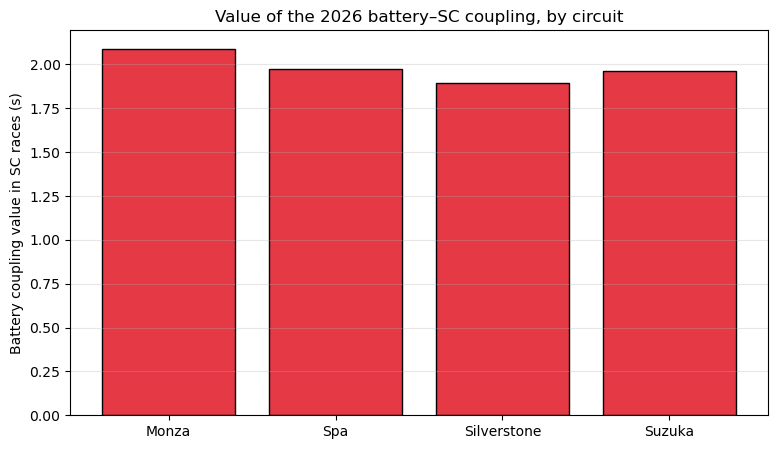

In [5]:
print(f"{'Circuit':12s} {'laps':>5s} {'pit OFF':>8s} {'pit ON':>7s} {'Δpit':>5s} {'val SC':>8s} {'val grn':>8s}")
print("-" * 60)
for name, r in results.items():
    dpit = (r['pit_on'] - r['pit_off']) if (r['pit_on'] and r['pit_off']) else 0
    print(f"{name:12s} {CIRCUITS[name]['n_laps']:>5d} {str(r['pit_off']):>8s} {str(r['pit_on']):>7s} "
          f"{dpit:>+5d} {r['val_sc']:>+7.2f}s {r['val_green']:>+7.2f}s")

names = list(results)
plt.figure(figsize=(9,5))
plt.bar(names, [results[n]['val_sc'] for n in names], color='#e63946', edgecolor='black')
plt.ylabel('Battery coupling value in SC races (s)')
plt.title('Value of the 2026 battery–SC coupling, by circuit')
plt.grid(axis='y', alpha=0.3)
plt.savefig('per_circuit_battery_value.png', dpi=200, bbox_inches='tight')
plt.show()